In [ ]:
# !pip install pydicom

<h3 style="color:cyan;"> Step 1 - Remove Private Tags Completely</h3>
<h3 style="color:cyan;"> Step 2 - Remove Private Tags Completely (HIPAA Safe Harbor: Remove/Change 18 elements related to the patient)</h3>
<h3 style="color:cyan;"> Step 3 - Date Shifting & Time Stripping</h3>
<h3 style="color:cyan;"> Step 4 - Step 4 - UID Logic & Referential Integrity</h3>
<h3 style="color:cyan;"> Step 5 - Audit Trail & Safe Storage</h3>


In [ ]:
import pydicom 

In [2]:
# Loading DICOM
dcm_path = "Velayati Hosein/061720243.dcm"
ds = pydicom.dcmread(dcm_path)

In [ ]:
ds.remove_private_tags()

In [2]:
ds.PatientName = "DOE^JOHN"
ds.PatientID = "SYNTHETIC_001"
ds.InstitutionName = "GENERAL_ACADEMIC_HOSPITAL"

In [4]:
ds

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 204
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.12.2.1107.5.2.53.190238.30000024070316065350300000465
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.410.200010.99.3.5
(0002,0013) Implementation Version Name         SH: 'INF_4.5'
(0002,0016) Source Application Entity Title     AE: 'AWP1902381'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'M', 'NORM', 'DIS3D', 'MFSPLIT']
(0008,0012) Instance Creation Date              DA: '20240617'
(0008,0013) Instance Creation Time              TM: '153934.755000'
(0008,0016) SOP C

In [5]:
ds.remove_private_tags()

In [7]:
ds

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 204
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.12.2.1107.5.2.53.190238.30000024070316065350300000465
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.410.200010.99.3.5
(0002,0013) Implementation Version Name         SH: 'INF_4.5'
(0002,0016) Source Application Entity Title     AE: 'AWP1902381'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'M', 'NORM', 'DIS3D', 'MFSPLIT']
(0008,0012) Instance Creation Date              DA: '20240617'
(0008,0013) Instance Creation Time              TM: '153934.755000'
(0008,0016) SOP C

In [ ]:
(0002,0000) File Meta Information Group Length  UL: 204
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.12.2.1107.5.2.53.190238.30000024070316065350300000465
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.826.0.1.3680043.8.498.35407086376303986525401131189063823065
(0002,0013) Implementation Version Name         SH: 'INF_4.5'
(0002,0016) Source Application Entity Title     AE: 'AWP1902381'

In [14]:
import datetime
ds.StudyDate

'20240617'

In [31]:
a = datetime.datetime.strptime(ds.StudyDate, "%Y%m%d")
a

datetime.datetime(2024, 6, 17, 0, 0)

In [32]:
print(a)

2024-06-17 00:00:00


In [39]:
b = a - datetime.timedelta(days=165)
b

datetime.datetime(2024, 1, 4, 0, 0)

In [45]:
b.strftime("%Y%m%d")

'20240104'

In [36]:
b

datetime.datetime(2024, 1, 4, 0, 0)

In [9]:
x = datetime.datetime(int(ds.AcquisitionDate[:4]),int(ds.AcquisitionDate[4:6]), int(ds.AcquisitionDate[6:8]))
a = datetime.timedelta(45)

In [30]:
a

datetime.datetime(2024, 6, 17, 0, 0)

In [35]:
print(x.strftime("%A"))

Saturday


In [51]:
ds.IssuerOfPatientID, ds.AcquisitionDateTime, ds.StudyDescription, ds.RelatedSeriesSequence, ds.BurnedInAnnotation

('', '20240617153934.755000', 'HEAD BR.epilepsy', <Sequence, length 1>, 'NO')

In [81]:
dicom_patterns = ["*.dcm", "*.DCM", "*.ima", "*.IMA"]
raw = y.glob("*.dcm")
for i in raw:
    print(i)

Velayati Hosein\061720240.dcm
Velayati Hosein\061720241.dcm
Velayati Hosein\0617202410.dcm
Velayati Hosein\06172024100.dcm
Velayati Hosein\06172024101.dcm
Velayati Hosein\06172024102.dcm
Velayati Hosein\06172024103.dcm
Velayati Hosein\06172024104.dcm
Velayati Hosein\06172024105.dcm
Velayati Hosein\06172024106.dcm
Velayati Hosein\06172024107.dcm
Velayati Hosein\06172024108.dcm
Velayati Hosein\06172024109.dcm
Velayati Hosein\0617202411.dcm
Velayati Hosein\06172024110.dcm
Velayati Hosein\06172024111.dcm
Velayati Hosein\06172024112.dcm
Velayati Hosein\06172024113.dcm
Velayati Hosein\06172024114.dcm
Velayati Hosein\06172024115.dcm
Velayati Hosein\06172024116.dcm
Velayati Hosein\06172024117.dcm
Velayati Hosein\06172024118.dcm
Velayati Hosein\06172024119.dcm
Velayati Hosein\0617202412.dcm
Velayati Hosein\06172024120.dcm
Velayati Hosein\06172024121.dcm
Velayati Hosein\06172024122.dcm
Velayati Hosein\06172024123.dcm
Velayati Hosein\06172024124.dcm
Velayati Hosein\06172024125.dcm
Velayati Hosein

In [20]:
from dicom_anonymizer import MedicalDicomAnonymizer
from pathlib import Path

def run_batch_anonymization() -> None:
    # ۱. دریافت ورودی‌ها به‌صورت تفکیک‌شده و شفاف
    input_dir_str = input("Enter the path of the raw DICOM directory: ").strip()
    pseudo_patient_id = input("Enter the pseudo patient ID (e.g., sub-001): ").strip()

    input_path = Path(input_dir_str)
    if not input_path.is_dir():
        print(f"Error: Directory '{input_dir_str}' does not exist.")
        return

    # ۲. ایجاد پوشه خروجی خارج از ساختار درونی داده‌های خام جهت پیشگیری از تداخل
    # Retuan a WindowsPath('Name_anonymized)
    # Path: C:/HospitalData/Patient_Velayati
    # علت معماری این کار؟
    # ا نمی‌خواهیم داده‌های گمنام‌شده درون همان پوشه اطلاعات محرمانه ریخته شوند
    # این کار ریسک مخلوط شدن فایل‌های خام و خروجی را از بین می‌برد.
    
    # این دستور یک پله به عقب برمی‌گردد و پوشه مادر (والد) را مشخص می‌کند. input_path.parent => C:/HospitalData
    # این دستور صرفاً نام پوشه نهایی را بدون بقیه مسیر استخراج می‌کند. input_path.name => Patient_Velayati
    # در اینجا عملگر تقسیم معادل Join
    # معادل تابع قدیمی os.path.join

    # current directory
    # output_path = input_path.parent / f"{input_path.name}_anonymized"
    
    # parent directory at Github.Project folder
    output_path = p = Path().cwd().resolve().parents[0] / f"{input_path.name}_anonymized"
    # output_path = input_path.parent / f"{input_path.name}_anonymized"
    # یک پوشه جدید در کنار پوشه خام اولیه تعریف می‌شود:
    # C:/HospitalData/Patient_Velayati_anonymized
    
    # creates parent folders, ignores if already exists
    # parents=True: Creates intermediate parent directories if they don't exist yet.
    # exist_ok=True: Prevents Python from throwing a FileExistsError if the directory already exists.
    output_path.mkdir(parents=True, exist_ok=True)

    # ۳. فیلتر امن فایل‌های دارای پسوند دایکام
    # gets only pattern files
    dicom_patterns = ["*.dcm"]
    raw_files = []
    for pattern in dicom_patterns:
        raw_files.extend(input_path.glob(pattern))
    
    # مرتب‌سازی الفبایی/عددی جهت حفظ توالی زمانی و فضایی اسلایس‌ها
    raw_files = sorted(raw_files)

    if not raw_files:
        print("No valid DICOM files found in the specified directory.")
        return

    # ۴. مقداردهی اولیه شیء گمنام‌ساز خارج از حلقه جهت نگهداری وضعیت UIDها
    anonymizer = MedicalDicomAnonymizer(shift_days=145)

    print(f"Starting de-identification for subject: {pseudo_patient_id}...")

    total_processed = 0
    for index, file_path in enumerate(raw_files, start=1):
        # نام‌گذاری خروجی: شناسه ثابت بیمار + شماره توالی اسلایس
        # index in 4 digit like 0001, 0002, etc.
        # sub-001_slice-0001.dcm
        output_file_name = f"{pseudo_patient_id}_slice-{index:04d}.dcm"
        # آدرس کامل فیزیکی برای ذخیره فایل روی هارد دیسک
        target_file_path = output_path / output_file_name
        # C:/HospitalData/Patient_Velayati_anonymized/sub-001_slice-0001.dcm
        try:
            # ارسال شناسه ثابت بیمار برای تمام اسلایس‌های متعلق به این اسکن
            anonymizer.process_file(
                input_path=str(file_path), # ۱. این فایل واقعی و خام را از دیسک بخوان
                output_path=str(target_file_path), # آدرس کامل فیزیکی روی هارد
                pseudo_patient_id=pseudo_patient_id
            )
            total_processed += 1
        except Exception as error:
            print(f"Failed to process {file_path.name}: {error}")

    print(f"\nSuccessfully processed and standardized {total_processed} files in: {output_path}")

if __name__ == "__main__":
    run_batch_anonymization()

Starting de-identification for subject: dcmNon...

Successfully processed and standardized 10 files in: D:\GitHub.Project\dcm-files_anonymized


In [8]:
ds

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 204
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.12.2.1107.5.2.53.190238.30000024070316065350300000465
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.410.200010.99.3.5
(0002,0013) Implementation Version Name         SH: 'INF_4.5'
(0002,0016) Source Application Entity Title     AE: 'AWP1902381'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'M', 'NORM', 'DIS3D', 'MFSPLIT']
(0008,0012) Instance Creation Date              DA: '20240617'
(0008,0013) Instance Creation Time              TM: '153934.755000'
(0008,0016) SOP C

In [61]:
ds[0x0021,0x1178]

(0021,1178) Private tag data                    UN: b'DIS3D '

In [ ]:
ds.remove_private_tags()

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 204
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.12.2.1107.5.2.53.190238.30000024070316065350300000465
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.410.200010.99.3.5
(0002,0013) Implementation Version Name         SH: 'INF_4.5'
(0002,0016) Source Application Entity Title     AE: 'AWP1902381'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'M', 'NORM', 'DIS3D', 'MFSPLIT']
(0008,0012) Instance Creation Date              DA: '20240617'
(0008,0013) Instance Creation Time              TM: '153934.755000'
(0008,0016) SOP C

In [67]:
import pydicom 
import matplotlib.pyplot as plt

# Loading DICOM
dcm_path = "Velayati Hosein/061720243.dcm"
ds = pydicom.dcmread(dcm_path)

In [ ]:
def apply_anonymization_audit_trail(ds: pydicom.Dataset) -> pydicom.Dataset:
    # 1. تغییر وضعیت هویتی فایل به تایید حذف داده‌های شناسنامه‌ای
    ds.PatientIdentityRemoved = 'YES'
    # 2. ثبت استاندارد و متدولوژی مهندسی اعمال‌شده
    ds.DeidentificationMethod = [
        'DICOM PS 3.15 Annex E Basic Profile',
        'HIPPA Safe Harbor De-identification',
        'Pseudonymized via SHA 256 remap'
    ]
    return ds

In [ ]:
# print ds base properties
print(f"""
Modality: {ds.Modality}
PatientID (Before Anon): {ds.PatientID}
Patient Name (Before Anon): {ds.PatientName}
Birtday (Before Anon): {ds.PatientBirthDate}
AccessionNumber (Before Anon): {ds.AccessionNumber}
Echo Time (TE): {ds.get('EchoTime', 'N/A')} ms
Repetition Time (RT): {ds.get('RepetitionTime', 'N/A')} ms
Magnetic Field: {ds.get('MagneticFieldStrength', 'N/A')} Tesla   
    """)


Modality: MR
PatientID (Before Anon): 14435417
Patient Name (Before Anon): VELAYATI HOSEIN
Birtday (Before Anon): 19620617
AccessionNumber (Before Anon): 1652765646
Echo Time (TE): 2.38 ms
Repetition Time (RT): 4.52 ms
Magnetic Field: 1.5 Tesla   
    


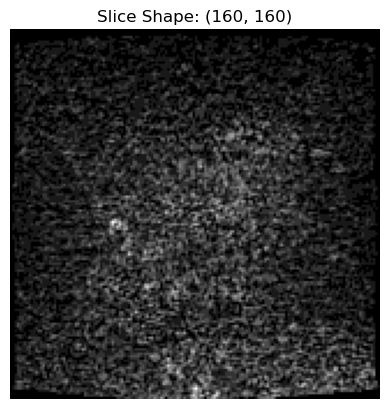

In [29]:
# Show image
pixed_array = ds.pixel_array
plt.imshow(pixed_array, cmap='gray')
plt.title(f"Slice Shape: {pixed_array.shape}") 
plt.axis('off')
plt.show()